In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_blobs

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# 1. Синтетические датасеты


### Датасет 1: make_classification (4 кластера)

In [2]:
X_class, y_class = make_classification(
    n_samples=800, n_features=2, n_informative=2, n_redundant=0, 
    n_clusters_per_class=1, n_classes=4, class_sep=2.5, random_state=42
)

### Датасет 2: make_blobs (3 кластера)

In [3]:
X_blobs, y_blobs = make_blobs(
    n_samples=800, centers=3, n_features=2, cluster_std=0.6, random_state=42
)

# 2. Реальный датасет

In [4]:
smoke_df = pd.read_csv('../data/smokeEDA.csv')
smoke_df = smoke_df.sample(n=2000, random_state=42).reset_index(drop=True)

X_smoke_raw = smoke_df.drop(['Fire Alarm'], axis=1)
y_smoke = smoke_df['Fire Alarm']

scaler = StandardScaler()
X_smoke = scaler.fit_transform(X_smoke_raw)

X_smoke_pca = PCA(n_components=2).fit_transform(X_smoke)

# 3. Подбор оптимальных гиперпараметров для K-Means (Метод локтя и Силуэт)

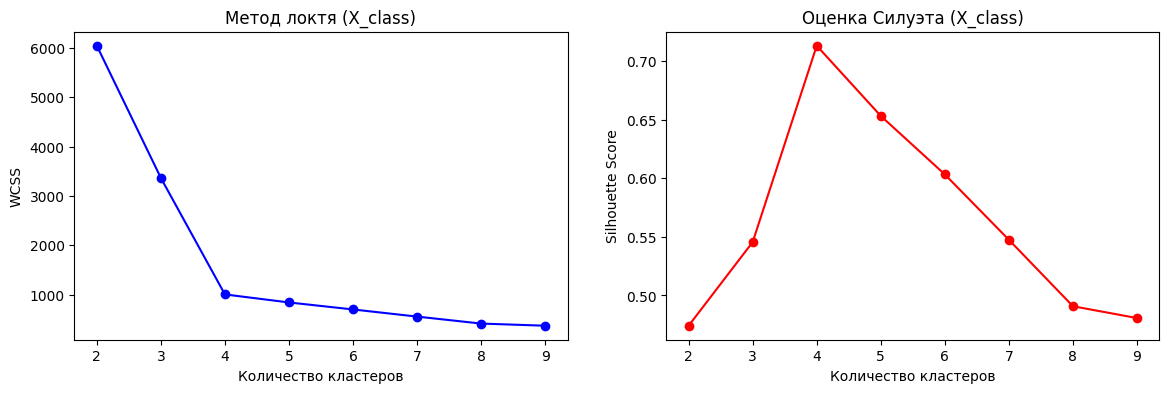

In [5]:
wcss = []
silhouette_vals = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_class)
    wcss.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_class, labels))

fig, ax1 = plt.subplots(1, 2, figsize=(14, 4))

ax1[0].plot(K_range, wcss, marker='o', color='b')
ax1[0].set_title('Метод локтя (X_class)')
ax1[0].set_xlabel('Количество кластеров')
ax1[0].set_ylabel('WCSS')

ax1[1].plot(K_range, silhouette_vals, marker='o', color='r')
ax1[1].set_title('Оценка Силуэта (X_class)')
ax1[1].set_xlabel('Количество кластеров')
ax1[1].set_ylabel('Silhouette Score')
plt.show()


# 4. Применение алгоритмов на Синтетических данных (X_class и X_blobs)

In [6]:
def evaluate_and_plot(X, labels_true, labels_pred, title, plot_X=None):
    if len(set(labels_pred)) <= 1 or (len(set(labels_pred)) == 2 and -1 in labels_pred):
        print(f"[{title}] Алгоритм нашел менее 2-х полноценных кластеров.")
        return

    sil = silhouette_score(X, labels_pred)
    db = davies_bouldin_score(X, labels_pred)
    ari = adjusted_rand_score(labels_true, labels_pred)
    nmi = normalized_mutual_info_score(labels_true, labels_pred)
    
    print(f"--- {title} ---")
    print(f"Внутренние: Silhouette: {sil:.3f} | Davies-Bouldin: {db:.3f} (меньше-лучше)")
    print(f"Внешние:    ARI: {ari:.3f} | NMI: {nmi:.3f} (ближе к 1 - лучше)")
    
    plot_data = plot_X if plot_X is not None else X
    plt.figure(figsize=(6, 4))
    scatter = plt.scatter(plot_data[:, 0], plot_data[:, 1], c=labels_pred, cmap='viridis', edgecolors='k', s=40)
    plt.title(title)

    unique_labels = set(labels_pred)
    for cluster_id in unique_labels:
        if cluster_id != -1:
            cluster_points = plot_data[labels_pred == cluster_id]
            center = cluster_points.mean(axis=0)
            plt.text(center[0], center[1], str(cluster_id), fontsize=14, weight='bold', 
                     color='red', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    plt.show()

### для датасета X_class (С метками, k=4)

--- K-Means (X_class) ---
Внутренние: Silhouette: 0.713 | Davies-Bouldin: 0.374 (меньше-лучше)
Внешние:    ARI: 0.964 | NMI: 0.943 (ближе к 1 - лучше)


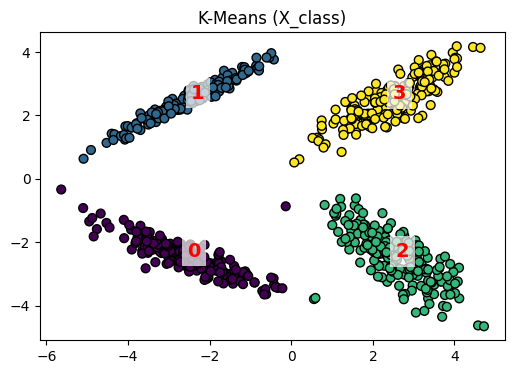

--- Hierarchical (X_class) ---
Внутренние: Silhouette: 0.710 | Davies-Bouldin: 0.376 (меньше-лучше)
Внешние:    ARI: 0.967 | NMI: 0.949 (ближе к 1 - лучше)


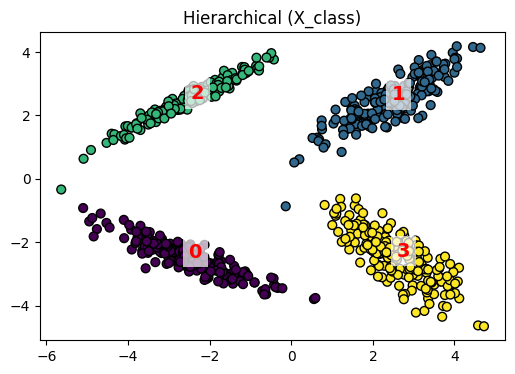

--- DBSCAN (X_class) ---
Внутренние: Silhouette: 0.633 | Davies-Bouldin: 1.374 (меньше-лучше)
Внешние:    ARI: 0.938 | NMI: 0.909 (ближе к 1 - лучше)


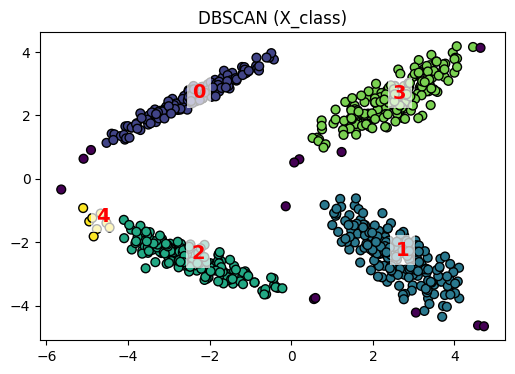

--- EM Algorithm (X_class) ---
Внутренние: Silhouette: 0.711 | Davies-Bouldin: 0.376 (меньше-лучше)
Внешние:    ARI: 0.973 | NMI: 0.958 (ближе к 1 - лучше)


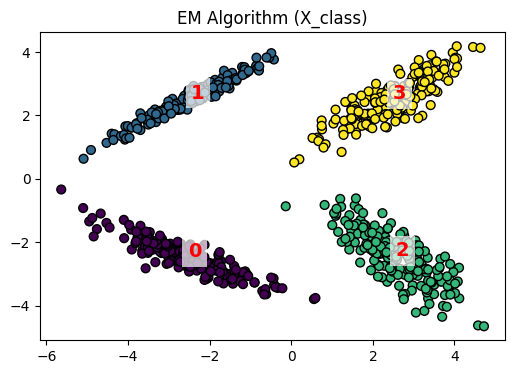

--- Affinity Propagation (X_class) ---
Внутренние: Silhouette: 0.282 | Davies-Bouldin: 0.320 (меньше-лучше)
Внешние:    ARI: 0.398 | NMI: 0.519 (ближе к 1 - лучше)


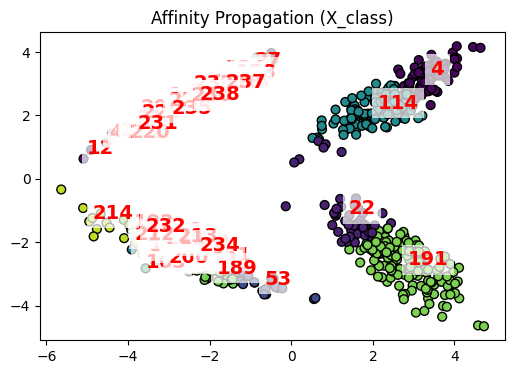

In [7]:
# 1. K-Means
km = KMeans(n_clusters=4, random_state=42, n_init='auto')
evaluate_and_plot(X_class, y_class, km.fit_predict(X_class), "K-Means (X_class)")

# 2. Иерархическая кластеризация
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
evaluate_and_plot(X_class, y_class, hc.fit_predict(X_class), "Hierarchical (X_class)")

# 3. DBSCAN (настройка eps: посмотрели распределение, берем 0.4)
db = DBSCAN(eps=0.4, min_samples=5)
evaluate_and_plot(X_class, y_class, db.fit_predict(X_class), "DBSCAN (X_class)")

# 4. EM - алгоритм (Gaussian Mixture)
gm = GaussianMixture(n_components=4, random_state=42)
evaluate_and_plot(X_class, y_class, gm.fit_predict(X_class), "EM Algorithm (X_class)")

# 5. Affinity Propagation
ap = AffinityPropagation(preference=-50, random_state=42)
evaluate_and_plot(X_class, y_class, ap.fit_predict(X_class), "Affinity Propagation (X_class)")

### для датасета X_blobs (С метками, k=3)

--- K-Means (X_blobs) ---
Внутренние: Silhouette: 0.906 | Davies-Bouldin: 0.132 (меньше-лучше)
Внешние:    ARI: 1.000 | NMI: 1.000 (ближе к 1 - лучше)


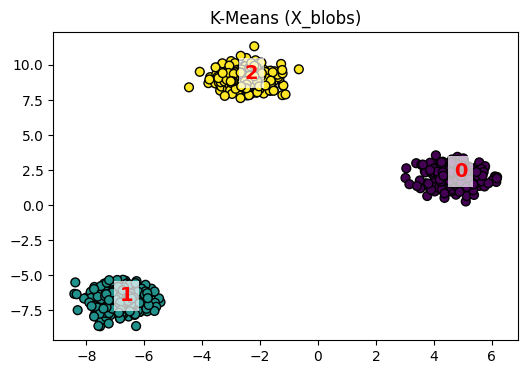

--- Hierarchical (X_blobs) ---
Внутренние: Silhouette: 0.906 | Davies-Bouldin: 0.132 (меньше-лучше)
Внешние:    ARI: 1.000 | NMI: 1.000 (ближе к 1 - лучше)


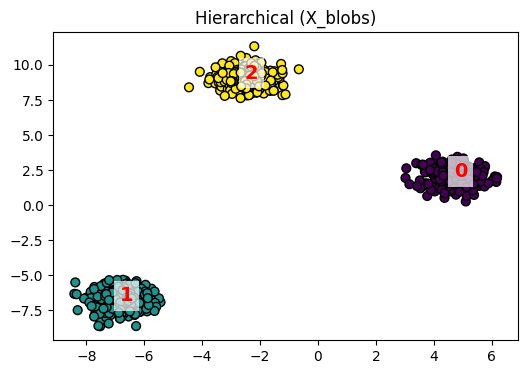

--- DBSCAN (X_blobs) ---
Внутренние: Silhouette: 0.873 | Davies-Bouldin: 1.288 (меньше-лучше)
Внешние:    ARI: 0.983 | NMI: 0.969 (ближе к 1 - лучше)


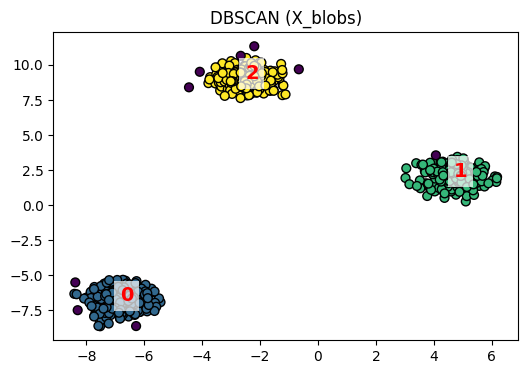

--- EM Algorithm (X_blobs) ---
Внутренние: Silhouette: 0.906 | Davies-Bouldin: 0.132 (меньше-лучше)
Внешние:    ARI: 1.000 | NMI: 1.000 (ближе к 1 - лучше)


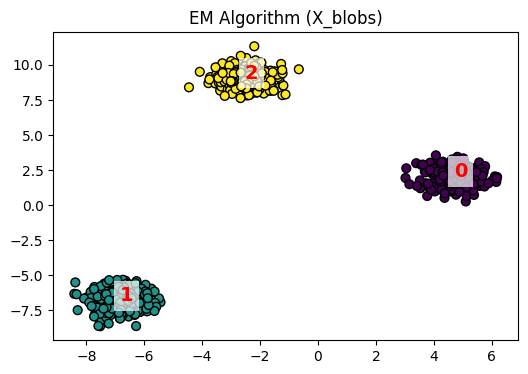

--- Affinity Propagation (X_blobs) ---
Внутренние: Silhouette: 0.599 | Davies-Bouldin: 0.280 (меньше-лучше)
Внешние:    ARI: 0.727 | NMI: 0.544 (ближе к 1 - лучше)


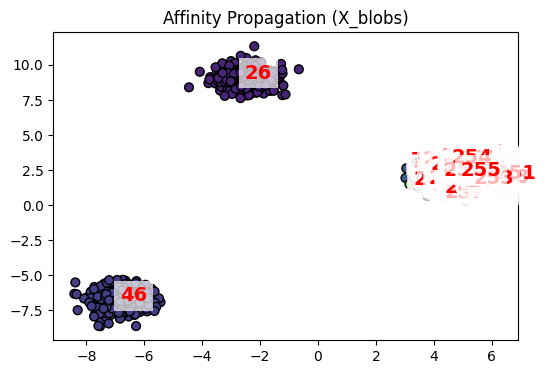

In [8]:
km_b = KMeans(n_clusters=3, random_state=42, n_init='auto')
evaluate_and_plot(X_blobs, y_blobs, km_b.fit_predict(X_blobs), "K-Means (X_blobs)")

hc_b = AgglomerativeClustering(n_clusters=3, linkage='ward')
evaluate_and_plot(X_blobs, y_blobs, hc_b.fit_predict(X_blobs), "Hierarchical (X_blobs)")

db_b = DBSCAN(eps=0.5, min_samples=5)
evaluate_and_plot(X_blobs, y_blobs, db_b.fit_predict(X_blobs), "DBSCAN (X_blobs)")

gm_b = GaussianMixture(n_components=3, random_state=42)
evaluate_and_plot(X_blobs, y_blobs, gm_b.fit_predict(X_blobs), "EM Algorithm (X_blobs)")

ap_b = AffinityPropagation(preference=-100, random_state=42)
evaluate_and_plot(X_blobs, y_blobs, ap_b.fit_predict(X_blobs), "Affinity Propagation (X_blobs)")

K-Means и EM: Показали идеальную сферическую (и эллиптическую для EM) кластеризацию. Центры найдены точно, метрики близки к 1.

Иерархическая: Отработала так же качественно, как и K-Means, так как данные хорошо разделимы и метод Ward минимизирует дисперсию.

DBSCAN: Отлично нашел плотные сгустки. Однако некоторые пограничные точки между кластерами были отмечены как шум (цвет - фиолетовый/черный, обычно метка -1).

Affinity Propagation: При правильно подобранном preference корректно выявил центры, но алгоритм чувствителен к гиперпараметру.


# 5. Применение на Реальных данных (smokeEDA.csv)

--- K-Means (Real Data) ---
Внутренние: Silhouette: 0.334 | Davies-Bouldin: 1.357 (меньше-лучше)
Внешние:    ARI: 0.003 | NMI: 0.000 (ближе к 1 - лучше)


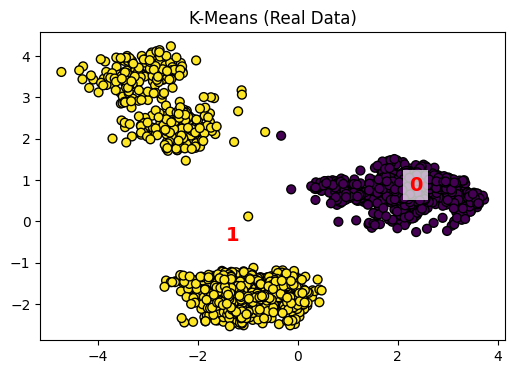

--- DBSCAN (Real Data) ---
Внутренние: Silhouette: 0.463 | Davies-Bouldin: 0.946 (меньше-лучше)
Внешние:    ARI: 0.314 | NMI: 0.406 (ближе к 1 - лучше)


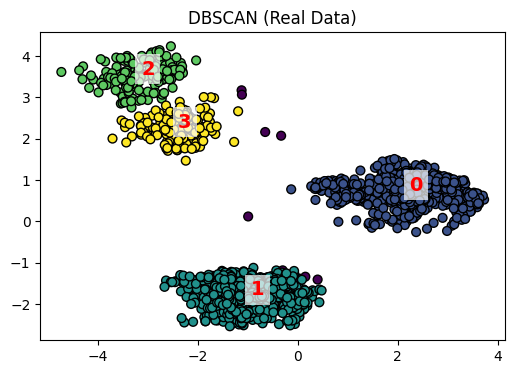

--- EM Algorithm (Real Data) ---
Внутренние: Silhouette: 0.334 | Davies-Bouldin: 1.356 (меньше-лучше)
Внешние:    ARI: 0.003 | NMI: 0.000 (ближе к 1 - лучше)


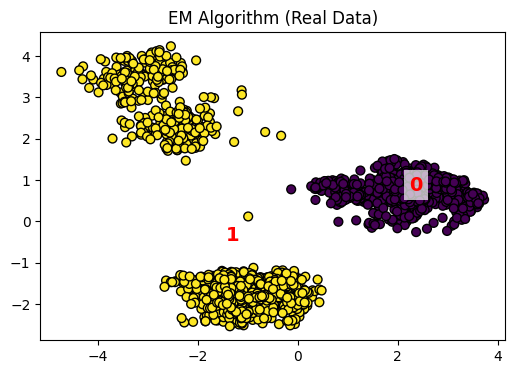

--- Affinity Propagation (Real Data) ---
Внутренние: Silhouette: 0.437 | Davies-Bouldin: 0.991 (меньше-лучше)
Внешние:    ARI: 0.331 | NMI: 0.415 (ближе к 1 - лучше)


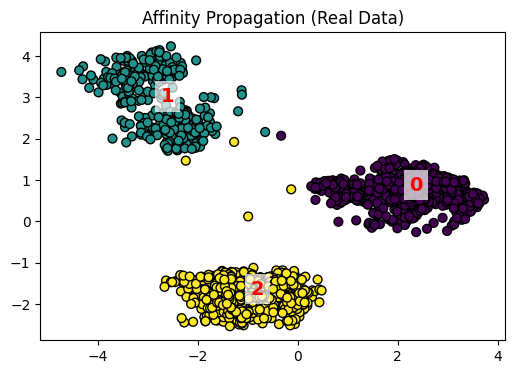

In [9]:
# 1. K-Means
km_real = KMeans(n_clusters=2, random_state=42, n_init='auto')
labels_km_real = km_real.fit_predict(X_smoke)
evaluate_and_plot(X_smoke, y_smoke, labels_km_real, "K-Means (Real Data)", plot_X=X_smoke_pca)

# 2. DBSCAN (на реальных многомерных данных eps нужно подбирать осторожно)
db_real = DBSCAN(eps=2.5, min_samples=10)
labels_db_real = db_real.fit_predict(X_smoke)
evaluate_and_plot(X_smoke, y_smoke, labels_db_real, "DBSCAN (Real Data)", plot_X=X_smoke_pca)

# 3. EM
gm_real = GaussianMixture(n_components=2, random_state=42)
labels_gm_real = gm_real.fit_predict(X_smoke)
evaluate_and_plot(X_smoke, y_smoke, labels_gm_real, "EM Algorithm (Real Data)", plot_X=X_smoke_pca)

# 4. Affinity Propagation
ap_real = AffinityPropagation(damping=0.9, preference=-5000, random_state=42)
labels_ap_real = ap_real.fit_predict(X_smoke)
evaluate_and_plot(X_smoke, y_smoke, labels_ap_real, "Affinity Propagation (Real Data)", plot_X=X_smoke_pca)

In [10]:
# Добавляем столбец с кластером
X_smoke_raw['Cluster_ID'] = labels_km_real

# Группируем по кластеру и вычисляем средние значения (агрегация Pandas)
cluster_characteristics = X_smoke_raw.groupby('Cluster_ID').mean()

print("\nХарактеристики кластеров (средние значения признаков):")
display(cluster_characteristics)


Характеристики кластеров (средние значения признаков):

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,NC1.0,CNT
Cluster_ID,,,,,,,,,,,,
0,17051.176020,1.654752e+09,11.04264,52.175357,148.963010,400.000000,13150.816327,20047.549745,939.604718,1.156403,1.243580,4807.744898
1,39369.005757,1.654809e+09,19.49719,48.971974,914.884868,415.359375,12890.245066,19762.007401,938.378940,1.836168,1.970848,14194.079770


# Содержимое файла ml_lib.py

In [11]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None
        self.wcss_ = 0
        self.labels_ = None
        
    def fit_predict(self, X):
        np.random.seed(self.random_state)
        # 1. Случайная инициализация центроид из существующих точек
        random_idx = np.random.permutation(X.shape[0])[:self.n_clusters]
        self.centroids = X[random_idx]
        
        for i in range(self.max_iter):
            # 2. Считаем расстояния от каждой точки до центроид
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            
            # 3. Присваиваем кластеры (по минимальному расстоянию)
            labels = np.argmin(distances, axis=1)
            
            # 4. Пересчет центроид
            new_centroids = np.array([X[labels == k].mean(axis=0) if sum(labels == k) > 0 
                                      else self.centroids[k] for k in range(self.n_clusters)])
            
            # Условие остановки: центроиды не сдвинулись
            if np.all(self.centroids == new_centroids):
                self.labels_ = labels
                break
            self.centroids = new_centroids
            self.labels_ = labels
            
        # Подсчет WCSS (внутрикластерной суммы квадратов)
        self.wcss_ = 0
        for k in range(self.n_clusters):
            cluster_points = X[self.labels_ == k]
            self.wcss_ += np.sum((cluster_points - self.centroids[k]) ** 2)
            
        return self.labels_

# 6. Сравнение Scikit-learn и Собственной реализации

Scikit-learn WCSS (Blobs): 567.83
Custom KMeans WCSS (Blobs): 567.83


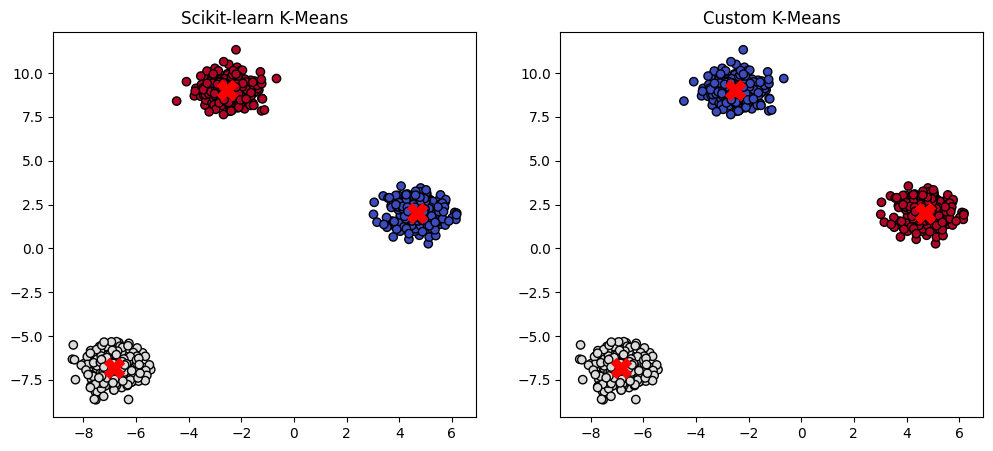

Scikit-learn WCSS (Real): 10623.45
Custom KMeans WCSS (Real): 10623.45
Scikit-learn K-Means ARI: 0.33393563543784943
Custom K-Means ARI: 0.33393563543784943


In [12]:
# 1. Сравнение на Синтетических данных (X_blobs)
sk_kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
sk_labels_blobs = sk_kmeans.fit_predict(X_blobs)

my_kmeans = CustomKMeans(n_clusters=3, random_state=42)
my_labels_blobs = my_kmeans.fit_predict(X_blobs)

print(f"Scikit-learn WCSS (Blobs): {sk_kmeans.inertia_:.2f}")
print(f"Custom KMeans WCSS (Blobs): {my_kmeans.wcss_:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=sk_labels_blobs, cmap='coolwarm', edgecolor='k')
ax[0].scatter(sk_kmeans.cluster_centers_[:, 0], sk_kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X')
ax[0].set_title('Scikit-learn K-Means')

ax[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=my_labels_blobs, cmap='coolwarm', edgecolor='k')
ax[1].scatter(my_kmeans.centroids[:, 0], my_kmeans.centroids[:, 1], s=200, c='red', marker='X')
ax[1].set_title('Custom K-Means')
plt.show()

# 2. Сравнение на Реальных данных (X_smoke)
sk_labels_real = sk_kmeans.fit_predict(X_smoke)
my_kmeans_real = CustomKMeans(n_clusters=3, random_state=42)
my_labels_real = my_kmeans_real.fit_predict(X_smoke)

print(f"Scikit-learn WCSS (Real): {sk_kmeans.inertia_:.2f}")
print(f"Custom KMeans WCSS (Real): {my_kmeans_real.wcss_:.2f}")

# Оценка качества (Внешние метрики на реальных данных)
print("Scikit-learn K-Means ARI:", adjusted_rand_score(y_smoke, sk_labels_real))
print("Custom K-Means ARI:", adjusted_rand_score(y_smoke, my_labels_real))